In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

# Add the project root to Python path (works from nested notebook folders)
_start_path = Path(__file__).resolve() if '__file__' in globals() else Path.cwd().resolve()
project_root = next((p for p in [_start_path, *_start_path.parents] if (p / 'ml_toolbox').exists()), None)
if project_root is None:
    raise RuntimeError('Could not locate project root containing ml_toolbox.')
sys.path.append(str(project_root))

from ml_toolbox.data_loader import create_label_to_class_map

saved_models_dir = project_root / "notebooks" / "test_output" / "history"
model_folders = [
    "both sensors files separated",
    "ch1ch2 sensors files separated",
    "ch3ch4 sensors files separated",
]
model_caches = [
    "4dbbc54272b81c2804c4761d605ac3dd0f5e92d2ec1defa55ce0c9e6a262b62c",
    "45654e2155e635f6c95d54c6b3a0c425995455a47a7d27559647d9d464a608bb",
    "1c71426c9de7fce0d4a2641b7cd0d6685be27ed7b861f18ca93a90fec97e8a43",
]

if len(model_folders) != len(model_caches):
    raise ValueError("model_folders and model_caches must have equal length")


def _window_identity(meta: dict) -> tuple:
    """Stable identity for one window row to validate cross-model alignment."""
    return (
        str(meta.get("sample_id", "")),
        str(meta.get("path", meta.get("absolute_path", ""))),
        str(meta.get("window_id", "")),
        int(meta.get("start_sample", -1)),
        int(meta.get("end_sample", -1)),
    )


def _validate_fold_coverage(shap_res: dict, n_samples: int) -> None:
    folds = list(shap_res.get("shap_values_per_fold", []))
    if len(folds) == 0:
        raise ValueError("shap_res['shap_values_per_fold'] is empty")

    covered = np.zeros(n_samples, dtype=np.int32)
    for fold_idx, fold in enumerate(folds):
        val_idx = np.asarray(fold["val_idx"], dtype=np.int32)
        if val_idx.ndim != 1:
            raise ValueError(f"Fold {fold_idx}: val_idx must be 1D, got shape={val_idx.shape}")
        if val_idx.size == 0:
            raise ValueError(f"Fold {fold_idx}: val_idx is empty")
        if val_idx.min() < 0 or val_idx.max() >= n_samples:
            raise ValueError(
                f"Fold {fold_idx}: val_idx out of bounds [{val_idx.min()}, {val_idx.max()}] for n={n_samples}"
            )
        covered[val_idx] += 1

    if np.any(covered == 0):
        missing_count = int(np.sum(covered == 0))
        raise ValueError(f"Some rows are not covered by validation folds: missing={missing_count}")
    if np.any(covered > 1):
        overlap_count = int(np.sum(covered > 1))
        raise ValueError(f"Some rows appear in multiple validation folds: overlaps={overlap_count}")


def _reconstruct_oof(shap_res: dict, features: np.ndarray, global_class_order: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """Reconstruct OOF hard predictions + class probabilities from fold estimators."""
    estimators = list(shap_res.get("estimators", []))
    if len(estimators) == 0:
        raise ValueError("shap_res does not contain estimators needed for OOF reconstruction")

    n_samples = features.shape[0]
    n_classes = len(global_class_order)

    y_pred_oof = np.empty(n_samples, dtype=np.int32)
    y_pred_oof.fill(-999999)
    y_proba_oof = np.full((n_samples, n_classes), np.nan, dtype=np.float64)
    seen = np.zeros(n_samples, dtype=np.int32)

    class_to_col = {int(c): idx for idx, c in enumerate(global_class_order)}

    for fold_idx, (estimator, val_idx) in enumerate(estimators):
        val_idx = np.asarray(val_idx, dtype=np.int32)
        X_val = features[val_idx]

        fold_pred = np.asarray(estimator.predict(X_val), dtype=np.int32)
        fold_proba = np.asarray(estimator.predict_proba(X_val), dtype=np.float64)
        est_classes = np.asarray(estimator.classes_, dtype=np.int32)

        if fold_pred.shape[0] != val_idx.shape[0]:
            raise ValueError(
                f"Fold {fold_idx}: predicted rows ({fold_pred.shape[0]}) != val_idx rows ({val_idx.shape[0]})"
            )
        if fold_proba.shape[0] != val_idx.shape[0]:
            raise ValueError(
                f"Fold {fold_idx}: proba rows ({fold_proba.shape[0]}) != val_idx rows ({val_idx.shape[0]})"
            )

        y_pred_oof[val_idx] = fold_pred

        for est_col_idx, class_label in enumerate(est_classes):
            class_label = int(class_label)
            if class_label not in class_to_col:
                raise ValueError(
                    f"Fold {fold_idx}: estimator class {class_label} not in global class order {global_class_order.tolist()}"
                )
            global_col_idx = class_to_col[class_label]
            y_proba_oof[val_idx, global_col_idx] = fold_proba[:, est_col_idx]

        seen[val_idx] += 1

    if np.any(seen == 0):
        missing = int(np.sum(seen == 0))
        raise ValueError(f"OOF reconstruction missing predictions for {missing} rows")
    if np.any(seen > 1):
        dup = int(np.sum(seen > 1))
        raise ValueError(f"OOF reconstruction wrote multiple predictions for {dup} rows")
    if np.any(np.isnan(y_proba_oof)):
        nan_count = int(np.isnan(y_proba_oof).sum())
        raise ValueError(f"OOF probability matrix still has NaN values: {nan_count}")

    return y_pred_oof, y_proba_oof


artifact_store: dict[str, dict] = {}
rows = []

for model_folder, cache_key in zip(model_folders, model_caches):
    run_dir = saved_models_dir / model_folder
    bundle_cache_path = run_dir / f"bundle_{cache_key}.joblib"
    eval_cache_path = run_dir / f"eval_res_{cache_key}.joblib"
    shap_cache_path = run_dir / f"shap_res_{cache_key}.joblib"

    bundle = joblib.load(bundle_cache_path)
    eval_res = joblib.load(eval_cache_path)
    shap_res = joblib.load(shap_cache_path)

    labels = np.asarray(bundle["labels"], dtype=np.int32)
    features = np.asarray(bundle["features"])
    feature_names = list(bundle["feature_names"])
    win_metadata = list(bundle["win_metadata"])

    if labels.shape[0] != features.shape[0] or labels.shape[0] != len(win_metadata):
        raise ValueError(
            f"Row mismatch in '{model_folder}': labels={labels.shape[0]}, features={features.shape[0]}, win_metadata={len(win_metadata)}"
        )

    _validate_fold_coverage(shap_res=shap_res, n_samples=labels.shape[0])

    unique_labels = np.asarray(eval_res.get("unique_labels", np.unique(labels)), dtype=np.int32)
    if unique_labels.ndim != 1:
        raise ValueError(f"unique_labels must be 1D, got shape={unique_labels.shape}")

    y_pred_oof, y_proba_oof = _reconstruct_oof(
        shap_res=shap_res,
        features=features,
        global_class_order=unique_labels,
    )

    label_to_class = create_label_to_class_map(win_metadata)
    class_names = [label_to_class.get(int(lbl), f"Class {int(lbl)}") for lbl in unique_labels]

    artifact_store[model_folder] = {
        "cache_key": cache_key,
        "bundle": bundle,
        "eval_res": eval_res,
        "shap_res": shap_res,
        "labels": labels,
        "features": features,
        "feature_names": feature_names,
        "win_metadata": win_metadata,
        "window_identity": [_window_identity(m) for m in win_metadata],
        "unique_labels": unique_labels,
        "class_names": class_names,
        "y_pred_oof": y_pred_oof,
        "y_proba_oof": y_proba_oof,
    }

    rows.append({
        "model_folder": model_folder,
        "n_samples": int(labels.shape[0]),
        "n_features": int(features.shape[1]),
        "n_classes": int(unique_labels.shape[0]),
        "cv_folds": int(len(shap_res.get("shap_values_per_fold", []))),
        "has_estimators": bool(len(shap_res.get("estimators", [])) > 0),
        "mean_accuracy(eval_res)": float(eval_res.get("mean_accuracy", np.nan)),
        "oof_accuracy(reconstructed)": float(np.mean(y_pred_oof == labels)),
    })

# Cross-model alignment checks
ref_model = model_folders[0]
ref_labels = artifact_store[ref_model]["labels"]
ref_identity = artifact_store[ref_model]["window_identity"]
ref_unique_labels = artifact_store[ref_model]["unique_labels"]

for model_folder in model_folders[1:]:
    model_data = artifact_store[model_folder]

    if not np.array_equal(model_data["labels"], ref_labels):
        raise ValueError(f"Label array mismatch between '{ref_model}' and '{model_folder}'")
    if model_data["window_identity"] != ref_identity:
        raise ValueError(f"Window identity order mismatch between '{ref_model}' and '{model_folder}'")
    if not np.array_equal(model_data["unique_labels"], ref_unique_labels):
        raise ValueError(f"unique_labels mismatch between '{ref_model}' and '{model_folder}'")

summary_df = pd.DataFrame(rows)
print("Loaded all model artifacts and reconstructed OOF predictions/probabilities.")
display(summary_df)

Loaded all model artifacts and reconstructed OOF predictions/probabilities.


,model_folder,n_samples,n_features,n_classes,cv_folds,has_estimators,mean_accuracy(eval_res),oof_accuracy(reconstructed)
0,both sensors files separated,19904,50,4,5,True,0.900144,0.900723
1,ch1ch2 sensors files separated,19904,26,4,5,True,0.885972,0.886957
2,ch3ch4 sensors files separated,19904,26,4,5,True,0.891681,0.891680


In [12]:
# SHAP sensor-group importance as percentages (overall + per-class + macro over classes)

import numpy as np
import pandas as pd

if "artifact_store" not in globals() or len(artifact_store) == 0:
    raise RuntimeError("artifact_store is not available. Run Cell 1 first.")

group_columns = [
    "ch1",
    "ch2",
    "ch3",
    "ch4",
    "ch1ch2",
    "ch3ch4",
    "speed",
    "load",
    "speed_load",
]

def _as_n_s_c_f(
    fold_shap_values: object,
    expected_n_features: int,
    expected_n_samples: int | None = None,
) -> np.ndarray:
    """Normalize fold SHAP values to shape (n_samples, n_classes, n_features)."""
    if isinstance(fold_shap_values, list):
        if len(fold_shap_values) == 0:
            raise ValueError("Received empty list for fold SHAP values")
        arr_list = [np.asarray(x, dtype=np.float64) for x in fold_shap_values]
        first_shape = arr_list[0].shape
        if len(first_shape) != 2:
            raise ValueError(f"Expected class SHAP matrix with 2 dims, got {first_shape}")
        n_samples, n_features = first_shape
        if n_features != expected_n_features:
            raise ValueError(
                f"List SHAP n_features={n_features} does not match expected={expected_n_features}"
            )
        for idx, arr in enumerate(arr_list):
            if arr.shape != first_shape:
                raise ValueError(
                    f"Inconsistent class SHAP shape in list at idx {idx}: {arr.shape} vs {first_shape}"
                )
        return np.stack(arr_list, axis=1)

    arr = np.asarray(fold_shap_values, dtype=np.float64)
    if arr.ndim == 2:
        n_samples, n_features = arr.shape
        if n_features != expected_n_features:
            raise ValueError(
                f"2D SHAP n_features={n_features} does not match expected={expected_n_features}"
            )
        return arr.reshape(n_samples, 1, n_features)

    if arr.ndim == 3:
        d0, d1, d2 = arr.shape
        feature_axis_candidates = [i for i, d in enumerate((d0, d1, d2)) if d == expected_n_features]
        if len(feature_axis_candidates) == 0:
            raise ValueError(
                f"3D SHAP shape {arr.shape} has no axis matching expected_n_features={expected_n_features}"
            )

        if 2 in feature_axis_candidates:
            feature_axis = 2
        else:
            feature_axis = feature_axis_candidates[0]

        arr_f_last = np.moveaxis(arr, feature_axis, -1)  # (?, ?, n_features)
        a, b, _ = arr_f_last.shape

        if expected_n_samples is not None and expected_n_samples in (a, b):
            sample_axis = 0 if a == expected_n_samples else 1
        else:
            sample_axis = 0 if a >= b else 1

        if sample_axis == 0:
            return arr_f_last
        return np.transpose(arr_f_last, (1, 0, 2))

    raise ValueError(f"Unsupported SHAP array layout with shape {arr.shape}")

def _group_indices(feature_names: list[str]) -> dict[str, list[int]]:
    ch1 = [i for i, n in enumerate(feature_names) if n.startswith("ch1_")]
    ch2 = [i for i, n in enumerate(feature_names) if n.startswith("ch2_")]
    ch3 = [i for i, n in enumerate(feature_names) if n.startswith("ch3_")]
    ch4 = [i for i, n in enumerate(feature_names) if n.startswith("ch4_")]

    speed = [i for i, n in enumerate(feature_names) if n in {"electrical_frequency_hz", "frequency_hz"}]
    load = [i for i, n in enumerate(feature_names) if n == "load"]
    speed_load = sorted(set(speed + load))

    return {
        "ch1": ch1,
        "ch2": ch2,
        "ch3": ch3,
        "ch4": ch4,
        "ch1ch2": ch1 + ch2,
        "ch3ch4": ch3 + ch4,
        "speed": speed,
        "load": load,
        "speed_load": speed_load,
    }

def _aggregate_groups(mean_abs_per_feature: np.ndarray, groups: dict[str, list[int]]) -> dict[str, float]:
    out = {}
    for group_name in group_columns:
        idx = groups[group_name]
        if len(idx) == 0:
            out[group_name] = np.nan
        else:
            out[group_name] = float(np.sum(mean_abs_per_feature[idx]))
    return out

def _to_percent(group_scores: dict[str, float], denom: float) -> dict[str, float]:
    out = {}
    for group_name in group_columns:
        val = group_scores[group_name]
        if np.isnan(val) or not np.isfinite(denom) or denom <= 0.0:
            out[group_name] = np.nan
        else:
            out[group_name] = float(100.0 * val / denom)
    return out

overall_rows = []
overall_pct_rows = []
per_class_rows = []
per_class_pct_rows = []

for model_folder in model_folders:
    model_data = artifact_store[model_folder]
    shap_res = model_data["shap_res"]
    feature_names = list(model_data["feature_names"])
    class_names = list(model_data["class_names"])
    unique_labels = np.asarray(model_data["unique_labels"], dtype=np.int32)

    folds = list(shap_res.get("shap_values_per_fold", []))
    if len(folds) == 0:
        raise ValueError(f"{model_folder}: shap_values_per_fold is empty")

    groups = _group_indices(feature_names)
    if sum(len(v) for v in groups.values()) == 0:
        raise ValueError(f"{model_folder}: none of requested groups found in feature_names")

    fold_arrays = []
    for fold_idx, fold in enumerate(folds):
        val_idx = np.asarray(fold.get("val_idx", []), dtype=np.int32)
        expected_n_samples = int(val_idx.shape[0]) if val_idx.ndim == 1 else None
        fold_arr = _as_n_s_c_f(
            fold["shap_values"],
            expected_n_features=len(feature_names),
            expected_n_samples=expected_n_samples,
        )
        if fold_arr.shape[2] != len(feature_names):
            raise ValueError(
                f"{model_folder} fold {fold_idx}: SHAP n_features={fold_arr.shape[2]} != feature_names={len(feature_names)}"
            )
        if expected_n_samples is not None and fold_arr.shape[0] != expected_n_samples:
            raise ValueError(
                f"{model_folder} fold {fold_idx}: SHAP n_samples={fold_arr.shape[0]} != val_idx n_samples={expected_n_samples}"
            )
        fold_arrays.append(fold_arr)

    all_shap = np.concatenate(fold_arrays, axis=0)  # (n_samples_total, n_classes, n_features)
    n_classes_shap = all_shap.shape[1]

    overall_mean_abs = np.mean(np.abs(all_shap), axis=(0, 1))
    overall_total_abs = float(np.sum(overall_mean_abs))
    overall_group_scores = _aggregate_groups(overall_mean_abs, groups)
    overall_rows.append({
        "model_folder": model_folder,
        **overall_group_scores,
    })
    overall_pct_rows.append({
        "model_folder": model_folder,
        **_to_percent(overall_group_scores, overall_total_abs),
    })

    n_classes_to_use = min(len(unique_labels), len(class_names), n_classes_shap)
    for class_idx in range(n_classes_to_use):
        class_mean_abs = np.mean(np.abs(all_shap[:, class_idx, :]), axis=0)
        class_total_abs = float(np.sum(class_mean_abs))
        class_group_scores = _aggregate_groups(class_mean_abs, groups)

        row_base = {
            "model_folder": model_folder,
            "class_label": int(unique_labels[class_idx]),
            "class_name": str(class_names[class_idx]),
        }

        per_class_rows.append({
            **row_base,
            **class_group_scores,
        })
        per_class_pct_rows.append({
            **row_base,
            **_to_percent(class_group_scores, class_total_abs),
        })

overall_group_importance_df = pd.DataFrame(overall_rows)
overall_group_importance_pct_df = pd.DataFrame(overall_pct_rows)
per_class_group_importance_df = pd.DataFrame(per_class_rows)
per_class_group_importance_pct_df = pd.DataFrame(per_class_pct_rows)

macro_group_importance_df = (
    per_class_group_importance_df
    .groupby("model_folder", observed=False)[group_columns]
    .mean()
    .reset_index()
)
macro_group_importance_pct_df = (
    per_class_group_importance_pct_df
    .groupby("model_folder", observed=False)[group_columns]
    .mean()
    .reset_index()
)

ordered_overall_cols = ["model_folder", *group_columns]
ordered_per_class_cols = ["model_folder", "class_label", "class_name", *group_columns]

overall_group_importance_df = overall_group_importance_df[ordered_overall_cols]
overall_group_importance_pct_df = overall_group_importance_pct_df[ordered_overall_cols]
per_class_group_importance_df = per_class_group_importance_df[ordered_per_class_cols]
per_class_group_importance_pct_df = per_class_group_importance_pct_df[ordered_per_class_cols]
macro_group_importance_df = macro_group_importance_df[["model_folder", *group_columns]]
macro_group_importance_pct_df = macro_group_importance_pct_df[["model_folder", *group_columns]]

print("SHAP sensor-group importance as percentage of total mean absolute SHAP per row.")
print("Note: groups overlap (e.g., ch1 + ch2 contributes to ch1ch2, speed/load contributes to speed_load),")
print("so percentages across all shown columns are not expected to sum to 100%.")

print("\nOverall (%) (all samples, macro over classes):")
display(overall_group_importance_pct_df.round(3))

print("\nPer-class (%):")
display(per_class_group_importance_pct_df.round(3))

print("\nMacro over classes (%) (equal class weight):")
display(macro_group_importance_pct_df.round(3))

SHAP sensor-group importance as percentage of total mean absolute SHAP per row.
Note: groups overlap (e.g., ch1 + ch2 contributes to ch1ch2, speed/load contributes to speed_load),
so percentages across all shown columns are not expected to sum to 100%.

Overall (%) (all samples, macro over classes):


,model_folder,ch1,ch2,ch3,ch4,ch1ch2,ch3ch4,speed,load,speed_load
0,both sensors files separated,23.004,21.326,24.618,24.866,44.330,49.484,5.985,0.201,6.187
1,ch1ch2 sensors files separated,43.815,46.746,NaN,NaN,90.562,NaN,8.947,0.491,9.438
2,ch3ch4 sensors files separated,NaN,NaN,45.026,46.756,NaN,91.782,7.933,0.285,8.218



Per-class (%):


,model_folder,class_label,class_name,ch1,ch2,ch3,ch4,ch1ch2,ch3ch4,speed,load,speed_load
0,both sensors files separated,0,d0,23.169,22.347,24.626,25.360,45.516,49.987,4.178,0.319,4.498
1,both sensors files separated,1,d3,18.240,20.460,26.469,23.292,38.700,49.760,11.312,0.228,11.540
2,both sensors files separated,2,d6,25.921,20.896,22.160,25.213,46.817,47.372,5.661,0.150,5.811
3,both sensors files separated,3,d9,24.528,21.690,25.508,25.633,46.219,51.142,2.530,0.110,2.640
4,ch1ch2 sensors files separated,0,d0,44.133,49.161,NaN,NaN,93.294,NaN,6.036,0.670,6.706
5,ch1ch2 sensors files separated,1,d3,35.902,47.177,NaN,NaN,83.079,NaN,16.341,0.580,16.921
6,ch1ch2 sensors files separated,2,d6,47.521,43.836,NaN,NaN,91.357,NaN,8.303,0.341,8.643
7,ch1ch2 sensors files separated,3,d9,47.650,47.228,NaN,NaN,94.878,NaN,4.730,0.392,5.122
8,ch3ch4 sensors files separated,0,d0,NaN,NaN,45.824,48.498,NaN,94.322,5.290,0.389,5.678
9,ch3ch4 sensors files separated,1,d3,NaN,NaN,43.365,41.676,NaN,85.041,14.647,0.313,14.959



Macro over classes (%) (equal class weight):


,model_folder,ch1,ch2,ch3,ch4,ch1ch2,ch3ch4,speed,load,speed_load
0,both sensors files separated,22.965,21.348,24.691,24.875,44.313,49.565,5.920,0.202,6.122
1,ch1ch2 sensors files separated,43.802,46.850,NaN,NaN,90.652,NaN,8.852,0.496,9.348
2,ch3ch4 sensors files separated,NaN,NaN,45.116,46.786,NaN,91.902,7.815,0.283,8.098


In [11]:
# Pairwise overlap categories using reconstructed OOF predictions

from itertools import combinations

overlap_rows = []

for sensor1, sensor2 in combinations(model_folders, 2):
    y_true = artifact_store[sensor1]["labels"]
    pred1 = artifact_store[sensor1]["y_pred_oof"]
    pred2 = artifact_store[sensor2]["y_pred_oof"]

    if not np.array_equal(y_true, artifact_store[sensor2]["labels"]):
        raise ValueError(f"Cannot compare '{sensor1}' and '{sensor2}': label mismatch")

    s1_correct = pred1 == y_true
    s2_correct = pred2 == y_true

    both_correct = int(np.sum(s1_correct & s2_correct))
    sensor1_only_correct = int(np.sum(s1_correct & (~s2_correct)))
    sensor2_only_correct = int(np.sum((~s1_correct) & s2_correct))
    both_wrong = int(np.sum((~s1_correct) & (~s2_correct)))

    total = int(y_true.shape[0])
    if both_correct + sensor1_only_correct + sensor2_only_correct + both_wrong != total:
        raise RuntimeError("Overlap category counts do not sum to total samples")

    overlap_rows.extend([
        {
            "sensor1": sensor1,
            "sensor2": sensor2,
            "category": "both_correct",
            "count": both_correct,
            "ratio": both_correct / total,
        },
        {
            "sensor1": sensor1,
            "sensor2": sensor2,
            "category": "sensor1_only_correct",
            "count": sensor1_only_correct,
            "ratio": sensor1_only_correct / total,
        },
        {
            "sensor1": sensor1,
            "sensor2": sensor2,
            "category": "sensor2_only_correct",
            "count": sensor2_only_correct,
            "ratio": sensor2_only_correct / total,
        },
        {
            "sensor1": sensor1,
            "sensor2": sensor2,
            "category": "both_wrong",
            "count": both_wrong,
            "ratio": both_wrong / total,
        },
    ])

overlap_df = pd.DataFrame(overlap_rows)
print("Pairwise error-overlap categories:")
display(overlap_df)

print("\nPivot view (counts):")
display(
    overlap_df.pivot_table(
        index=["sensor1", "sensor2"],
        columns="category",
        values="count",
        aggfunc="sum",
    ).reset_index()
)

Pairwise error-overlap categories:


,sensor1,sensor2,category,count,ratio
0,both sensors files separated,ch1ch2 sensors files separated,both_correct,17071,0.857667
1,both sensors files separated,ch1ch2 sensors files separated,sensor1_only_correct,857,0.043057
2,both sensors files separated,ch1ch2 sensors files separated,sensor2_only_correct,583,0.029291
3,both sensors files separated,ch1ch2 sensors files separated,both_wrong,1393,0.069986
4,both sensors files separated,ch3ch4 sensors files separated,both_correct,17147,0.861485
5,both sensors files separated,ch3ch4 sensors files separated,sensor1_only_correct,781,0.039238
6,both sensors files separated,ch3ch4 sensors files separated,sensor2_only_correct,601,0.030195
7,both sensors files separated,ch3ch4 sensors files separated,both_wrong,1375,0.069082
8,ch1ch2 sensors files separated,ch3ch4 sensors files separated,both_correct,16437,0.825814
9,ch1ch2 sensors files separated,ch3ch4 sensors files separated,sensor1_only_correct,1217,0.061143



Pivot view (counts):


category,sensor1,sensor2,both_correct,both_wrong,sensor1_only_correct,sensor2_only_correct
0,both sensors files separated,ch1ch2 sensors files separated,17071,1393,857,583
1,both sensors files separated,ch3ch4 sensors files separated,17147,1375,781,601
2,ch1ch2 sensors files separated,ch3ch4 sensors files separated,16437,939,1217,1311


In [3]:
# Multiclass ROC-AUC (One-vs-Rest), including per-class AUC

from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

roc_rows = []

for model_folder in model_folders:
    model_data = artifact_store[model_folder]
    y_true = model_data["labels"]
    y_proba = model_data["y_proba_oof"]
    unique_labels = np.asarray(model_data["unique_labels"], dtype=np.int32)
    class_names = list(model_data["class_names"])

    if y_proba.shape[0] != y_true.shape[0]:
        raise ValueError(
            f"{model_folder}: probability rows {y_proba.shape[0]} != labels {y_true.shape[0]}"
        )
    if y_proba.shape[1] != unique_labels.shape[0]:
        raise ValueError(
            f"{model_folder}: probability cols {y_proba.shape[1]} != classes {unique_labels.shape[0]}"
        )

    row_sums = np.sum(y_proba, axis=1)
    if not np.all(np.isfinite(row_sums)):
        raise ValueError(f"{model_folder}: non-finite values in probability matrix")
    if not np.allclose(row_sums, 1.0, atol=1e-6):
        max_dev = float(np.max(np.abs(row_sums - 1.0)))
        print(f"Warning: {model_folder} probability row sums deviate from 1.0 (max dev={max_dev:.2e})")

    y_true_bin = label_binarize(y_true, classes=unique_labels)

    auc_macro = roc_auc_score(y_true_bin, y_proba, average="macro", multi_class="ovr")
    auc_weighted = roc_auc_score(y_true_bin, y_proba, average="weighted", multi_class="ovr")

    roc_rows.append({
        "model_folder": model_folder,
        "scope": "overall",
        "class_label": "macro_ovr",
        "class_name": "macro_ovr",
        "roc_auc": float(auc_macro),
    })
    roc_rows.append({
        "model_folder": model_folder,
        "scope": "overall",
        "class_label": "weighted_ovr",
        "class_name": "weighted_ovr",
        "roc_auc": float(auc_weighted),
    })

    for class_col, class_label in enumerate(unique_labels):
        y_true_one_vs_rest = y_true_bin[:, class_col]
        if np.unique(y_true_one_vs_rest).size < 2:
            auc_val = np.nan
        else:
            auc_val = roc_auc_score(y_true_one_vs_rest, y_proba[:, class_col])

        roc_rows.append({
            "model_folder": model_folder,
            "scope": "per_class",
            "class_label": int(class_label),
            "class_name": class_names[class_col],
            "roc_auc": float(auc_val) if np.isfinite(auc_val) else np.nan,
        })

roc_auc_df = pd.DataFrame(roc_rows)
print("ROC-AUC OvR summary:")
display(roc_auc_df)

print("\nPer-class pivot table:")
display(
    roc_auc_df[roc_auc_df["scope"] == "per_class"]
    .pivot_table(index="model_folder", columns="class_name", values="roc_auc", aggfunc="mean")
    .reset_index()
)

ROC-AUC OvR summary:


,model_folder,scope,class_label,class_name,roc_auc
0,both sensors files separated,overall,macro_ovr,macro_ovr,0.984133
1,both sensors files separated,overall,weighted_ovr,weighted_ovr,0.984133
2,both sensors files separated,per_class,0,d0,0.979611
3,both sensors files separated,per_class,1,d3,0.959463
4,both sensors files separated,per_class,2,d6,0.997898
5,both sensors files separated,per_class,3,d9,0.999558
6,ch1ch2 sensors files separated,overall,macro_ovr,macro_ovr,0.983593
7,ch1ch2 sensors files separated,overall,weighted_ovr,weighted_ovr,0.983593
8,ch1ch2 sensors files separated,per_class,0,d0,0.977221
9,ch1ch2 sensors files separated,per_class,1,d3,0.964681



Per-class pivot table:


class_name,model_folder,d0,d3,d6,d9
0,both sensors files separated,0.979611,0.959463,0.997898,0.999558
1,ch1ch2 sensors files separated,0.977221,0.964681,0.995140,0.997330
2,ch3ch4 sensors files separated,0.979701,0.960467,0.997226,0.999467


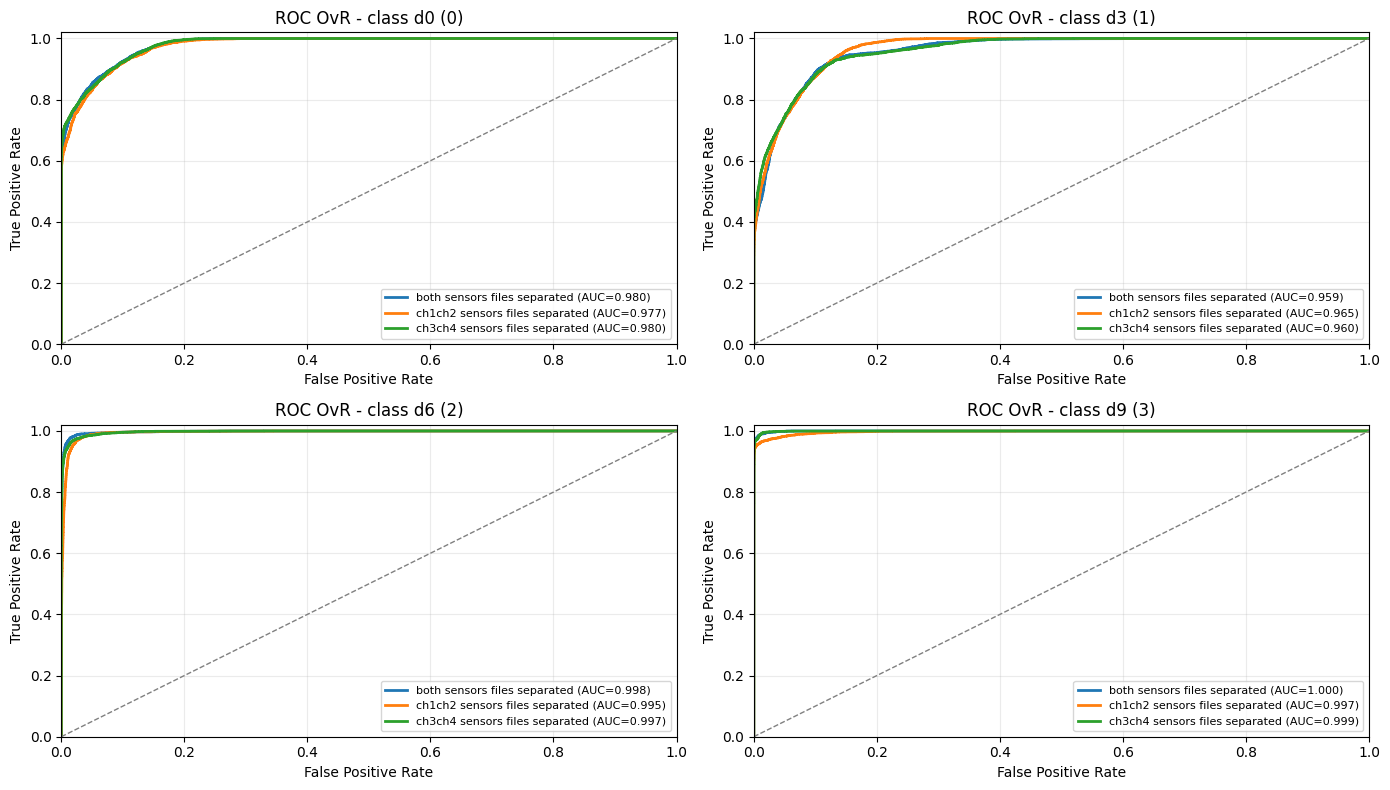

In [4]:
# ROC curves: per class, per model (One-vs-Rest)

import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

n_models = len(model_folders)
ref_unique_labels = np.asarray(artifact_store[model_folders[0]]["unique_labels"], dtype=np.int32)
ref_class_names = list(artifact_store[model_folders[0]]["class_names"])

n_classes = len(ref_unique_labels)
n_cols = 2
n_rows = int(math.ceil(n_classes / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), squeeze=False)

for class_idx, class_label in enumerate(ref_unique_labels):
    r = class_idx // n_cols
    c = class_idx % n_cols
    ax = axes[r, c]

    for model_folder in model_folders:
        model_data = artifact_store[model_folder]
        y_true = np.asarray(model_data["labels"], dtype=np.int32)
        y_proba = np.asarray(model_data["y_proba_oof"], dtype=float)
        unique_labels = np.asarray(model_data["unique_labels"], dtype=np.int32)

        if not np.array_equal(unique_labels, ref_unique_labels):
            raise ValueError(
                f"Class order mismatch: '{model_folder}' has {unique_labels.tolist()}, expected {ref_unique_labels.tolist()}"
            )

        y_true_bin = label_binarize(y_true, classes=unique_labels)[:, class_idx]
        y_score = y_proba[:, class_idx]

        if np.unique(y_true_bin).size < 2:
            continue

        fpr, tpr, _ = roc_curve(y_true_bin, y_score)
        roc_auc = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, label=f"{model_folder} (AUC={roc_auc:.3f})")

    ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)
    ax.set_title(f"ROC OvR - class {ref_class_names[class_idx]} ({int(class_label)})")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.02)
    ax.grid(alpha=0.25)
    ax.legend(loc="lower right", fontsize=8)

# Hide any unused subplot axes
for idx in range(n_classes, n_rows * n_cols):
    r = idx // n_cols
    c = idx % n_cols
    axes[r, c].axis("off")

plt.tight_layout()
plt.show()

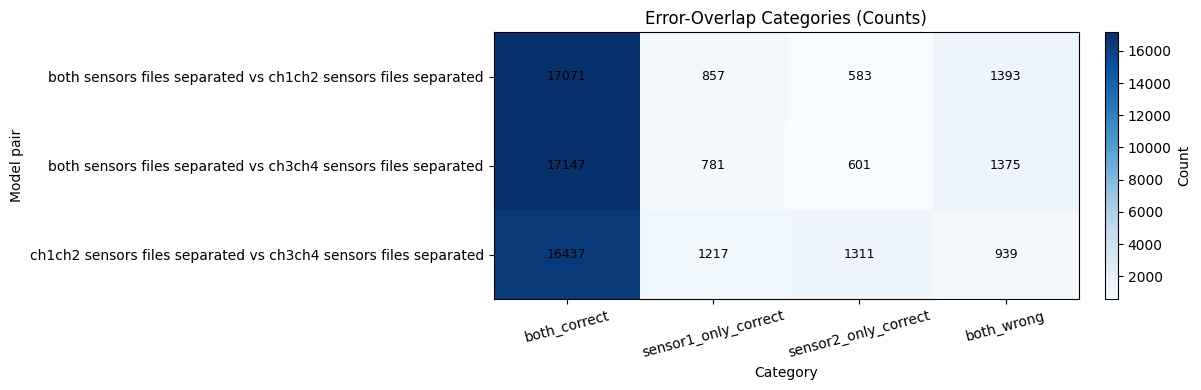

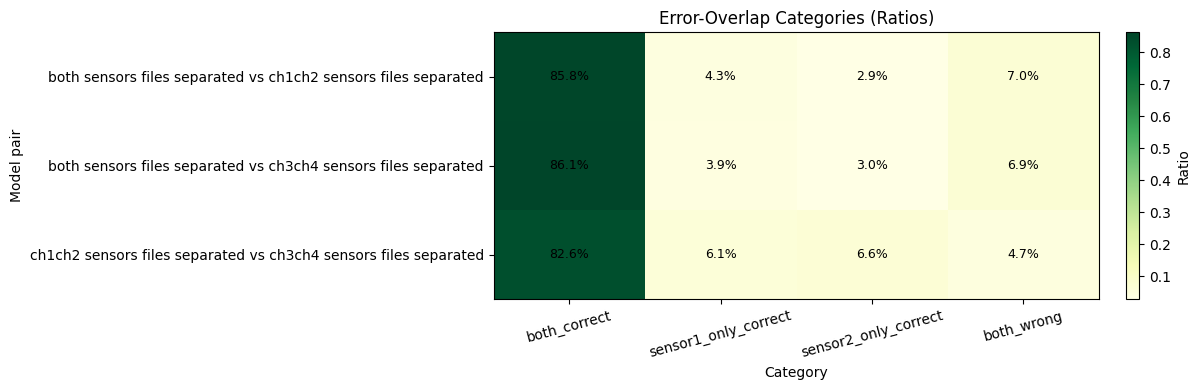

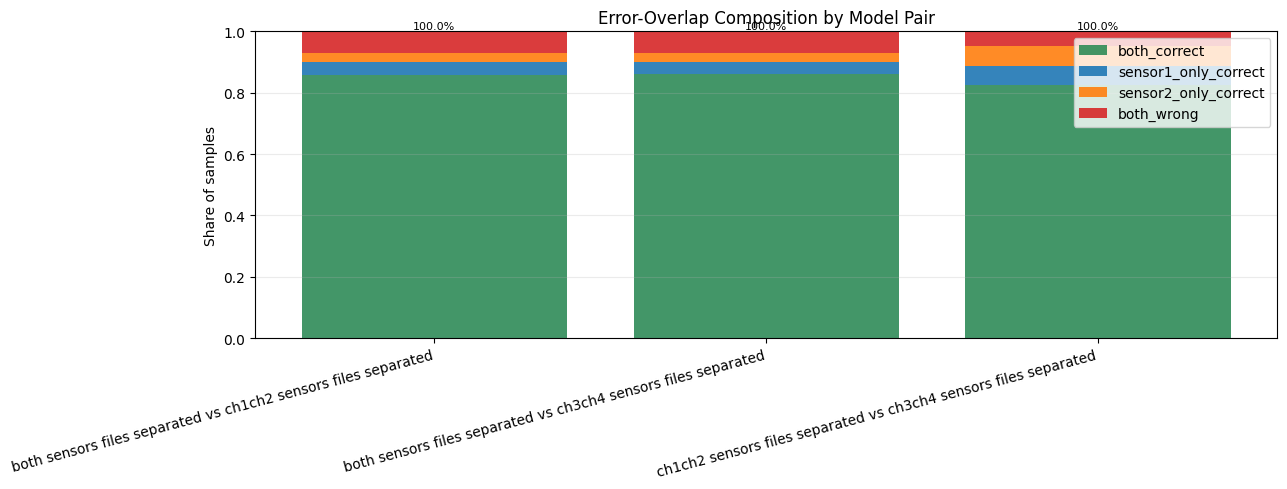

In [ ]:
# Overlap visualizations: heatmaps + stacked bar chart

import numpy as np
import matplotlib.pyplot as plt

required_categories = [
    "both_correct",
    "sensor1_only_correct",
    "sensor2_only_correct",
    "both_wrong",
]

overlap_counts = (
    overlap_df.pivot_table(
        index=["sensor1", "sensor2"],
        columns="category",
        values="count",
        aggfunc="sum",
    )
    .reindex(columns=required_categories)
    .fillna(0)
)
overlap_ratios = (
    overlap_df.pivot_table(
        index=["sensor1", "sensor2"],
        columns="category",
        values="ratio",
        aggfunc="sum",
    )
    .reindex(columns=required_categories)
    .fillna(0.0)
)

pair_labels = [f"{a} vs {b}" for a, b in overlap_counts.index.to_list()]

# 1) Heatmap for counts
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(overlap_counts.values, aspect="auto", cmap="Blues")
ax.set_title("Error-Overlap Categories (Counts)")
ax.set_xticks(np.arange(len(required_categories)))
ax.set_xticklabels(required_categories, rotation=15)
ax.set_yticks(np.arange(len(pair_labels)))
ax.set_yticklabels(pair_labels)
ax.set_xlabel("Category")
ax.set_ylabel("Model pair")

for i in range(overlap_counts.shape[0]):
    for j in range(overlap_counts.shape[1]):
        ax.text(j, i, f"{int(overlap_counts.values[i, j])}", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Count")
plt.tight_layout()
plt.show()

# 2) Heatmap for ratios
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(overlap_ratios.values, aspect="auto", cmap="YlGn")
ax.set_title("Error-Overlap Categories (Ratios)")
ax.set_xticks(np.arange(len(required_categories)))
ax.set_xticklabels(required_categories, rotation=15)
ax.set_yticks(np.arange(len(pair_labels)))
ax.set_yticklabels(pair_labels)
ax.set_xlabel("Category")
ax.set_ylabel("Model pair")

for i in range(overlap_ratios.shape[0]):
    for j in range(overlap_ratios.shape[1]):
        ax.text(j, i, f"{overlap_ratios.values[i, j] * 100:.1f}%", ha="center", va="center", fontsize=9)

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Ratio")
plt.tight_layout()
plt.show()

# 3) Stacked bar chart (ratios) for quick pairwise comparison
x = np.arange(len(pair_labels))
width = 0.8
bottom = np.zeros(len(pair_labels), dtype=float)

palette = {
    "both_correct": "#2E8B57",
    "sensor1_only_correct": "#1f77b4",
    "sensor2_only_correct": "#ff7f0e",
    "both_wrong": "#d62728",
}

fig, ax = plt.subplots(figsize=(13, 5))
for cat in required_categories:
    vals = overlap_ratios[cat].to_numpy(dtype=float)
    ax.bar(x, vals, width, bottom=bottom, label=cat, color=palette[cat], alpha=0.9)
    bottom += vals

ax.set_title("Error-Overlap Composition by Model Pair")
ax.set_xticks(x)
ax.set_xticklabels(pair_labels, rotation=15, ha="right")
ax.set_ylabel("Share of samples")
ax.set_ylim(0.0, 1.0)
ax.grid(axis="y", alpha=0.25)
ax.legend(loc="upper right")

for i, total in enumerate(bottom):
    ax.text(i, min(total + 0.01, 1.0), f"{total * 100:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

In [2]:
# Disagreement diagnostics: class/speed/load composition for one sensor pair

import numpy as np
import pandas as pd

# Choose the pair to analyze deeply.
# This default matches the pair where both_wrong was 939 in your earlier output.
sensor1_model = "ch1ch2 sensors files separated"
sensor2_model = "ch3ch4 sensors files separated"

if sensor1_model not in artifact_store or sensor2_model not in artifact_store:
    raise ValueError("Selected sensor model names are not available in artifact_store")

m1 = artifact_store[sensor1_model]
m2 = artifact_store[sensor2_model]

if not np.array_equal(m1["labels"], m2["labels"]):
    raise ValueError("Label arrays mismatch between selected models")
if m1["window_identity"] != m2["window_identity"]:
    raise ValueError("Window identity mismatch between selected models")

labels = np.asarray(m1["labels"], dtype=np.int32)
pred1 = np.asarray(m1["y_pred_oof"], dtype=np.int32)
pred2 = np.asarray(m2["y_pred_oof"], dtype=np.int32)
meta = list(m1["win_metadata"])

if len(meta) != labels.shape[0]:
    raise ValueError("win_metadata length does not match labels")

label_to_class = {int(k): str(v) for k, v in zip(m1["unique_labels"], m1["class_names"])}

s1_correct = pred1 == labels
s2_correct = pred2 == labels

mask_sensor1_only = s1_correct & (~s2_correct)
mask_sensor2_only = (~s1_correct) & s2_correct
mask_both_wrong = (~s1_correct) & (~s2_correct)

analysis_df = pd.DataFrame({
    "true_label": labels,
    "true_class": [label_to_class.get(int(y), f"Class {int(y)}") for y in labels],
    "sensor1_pred": pred1,
    "sensor2_pred": pred2,
    "sensor1_correct": s1_correct,
    "sensor2_correct": s2_correct,
    "electrical_frequency_hz": [m.get("electrical_frequency_hz", np.nan) for m in meta],
    "load": [m.get("load", "unknown") for m in meta],
})

analysis_df["group"] = "both_correct"
analysis_df.loc[mask_sensor1_only, "group"] = "sensor1_only_correct"
analysis_df.loc[mask_sensor2_only, "group"] = "sensor2_only_correct"
analysis_df.loc[mask_both_wrong, "group"] = "both_wrong"

focus_groups = ["sensor1_only_correct", "sensor2_only_correct", "both_wrong"]

summary_counts = (
    analysis_df[analysis_df["group"].isin(focus_groups)]
    .groupby("group", observed=False)
    .size()
    .rename("count")
    .reset_index()
)
print(f"Analyzed pair: {sensor1_model} vs {sensor2_model}")
display(summary_counts)

# A) Which classes dominate disagreements?
print("\nA) True-class distribution in disagreement groups")
class_counts = (
    analysis_df[analysis_df["group"].isin(focus_groups)]
    .groupby(["group", "true_class"], observed=False)
    .size()
    .rename("count")
    .reset_index()
)
class_totals = class_counts.groupby("group", observed=False)["count"].transform("sum")
class_counts["ratio"] = class_counts["count"] / class_totals
class_counts = class_counts.sort_values(["group", "count"], ascending=[True, False]).reset_index(drop=True)
display(class_counts)

print("\nClass distribution pivot (%):")
display(
    class_counts.pivot_table(
        index="group",
        columns="true_class",
        values="ratio",
        aggfunc="sum",
    )
    .fillna(0.0)
    .round(4)
)

# B) Which speeds and loads produce disagreement?
print("\nB1) electrical_frequency_hz distribution by disagreement group")
freq_counts = (
    analysis_df[analysis_df["group"].isin(focus_groups)]
    .groupby(["group", "electrical_frequency_hz"], observed=False)
    .size()
    .rename("count")
    .reset_index()
)
freq_totals = freq_counts.groupby("group", observed=False)["count"].transform("sum")
freq_counts["ratio"] = freq_counts["count"] / freq_totals
freq_counts = freq_counts.sort_values(["group", "count"], ascending=[True, False]).reset_index(drop=True)
display(freq_counts)

print("\nSpeed distribution pivot (%):")
display(
    freq_counts.pivot_table(
        index="group",
        columns="electrical_frequency_hz",
        values="ratio",
        aggfunc="sum",
    )
    .fillna(0.0)
    .round(4)
)

print("\nB2) load distribution by disagreement group")
load_counts = (
    analysis_df[analysis_df["group"].isin(focus_groups)]
    .groupby(["group", "load"], observed=False)
    .size()
    .rename("count")
    .reset_index()
)
load_totals = load_counts.groupby("group", observed=False)["count"].transform("sum")
load_counts["ratio"] = load_counts["count"] / load_totals
load_counts = load_counts.sort_values(["group", "count"], ascending=[True, False]).reset_index(drop=True)
display(load_counts)

print("\nLoad distribution pivot (%):")
display(
    load_counts.pivot_table(
        index="group",
        columns="load",
        values="ratio",
        aggfunc="sum",
    )
    .fillna(0.0)
    .round(4)
)

# Explicit deep-dive for both_wrong slice (expected 939 for this pair)
both_wrong_df = analysis_df[analysis_df["group"] == "both_wrong"].copy()
print(f"\nBoth-wrong sample count: {len(both_wrong_df)}")

print("\nBoth-wrong: true class distribution")
display(
    both_wrong_df.groupby("true_class", observed=False)
    .size()
    .rename("count")
    .sort_values(ascending=False)
    .to_frame()
)

print("\nBoth-wrong: electrical_frequency_hz distribution")
display(
    both_wrong_df.groupby("electrical_frequency_hz", observed=False)
    .size()
    .rename("count")
    .sort_values(ascending=False)
    .to_frame()
)

print("\nBoth-wrong: load distribution")
display(
    both_wrong_df.groupby("load", observed=False)
    .size()
    .rename("count")
    .sort_values(ascending=False)
    .to_frame()
)

# Keep results accessible for later plotting/export
disagreement_analysis = {
    "pair": (sensor1_model, sensor2_model),
    "summary_counts": summary_counts,
    "class_counts": class_counts,
    "freq_counts": freq_counts,
    "load_counts": load_counts,
    "both_wrong_df": both_wrong_df,
}

Analyzed pair: ch1ch2 sensors files separated vs ch3ch4 sensors files separated


,group,count
0,both_wrong,939
1,sensor1_only_correct,1217
2,sensor2_only_correct,1311



A) True-class distribution in disagreement groups


,group,true_class,count,ratio
0,both_wrong,d3,492,0.523962
1,both_wrong,d0,371,0.395101
2,both_wrong,d9,43,0.045793
3,both_wrong,d6,33,0.035144
4,sensor1_only_correct,d3,559,0.459326
5,sensor1_only_correct,d0,399,0.327855
6,sensor1_only_correct,d6,214,0.175842
7,sensor1_only_correct,d9,45,0.036976
8,sensor2_only_correct,d3,638,0.486651
9,sensor2_only_correct,d0,373,0.284516



Class distribution pivot (%):


...

,count
true_class,
d3,492
d0,371
d9,43
d6,33



Both-wrong: electrical_frequency_hz distribution


,count
electrical_frequency_hz,
20,724
50,167
30,48



Both-wrong: load distribution


,count
load,
0.1,709
0.0,230


## Article-Ready Disagreement Visuals

These figures convert disagreement composition into normalized percentages for fair comparison across groups with different sample sizes.

- Focus groups: `sensor1_only_correct`, `sensor2_only_correct`, `both_wrong`
- Percentages are computed **within each group** (row-normalized)
- Heatmaps are intended for direct use in reports/articles

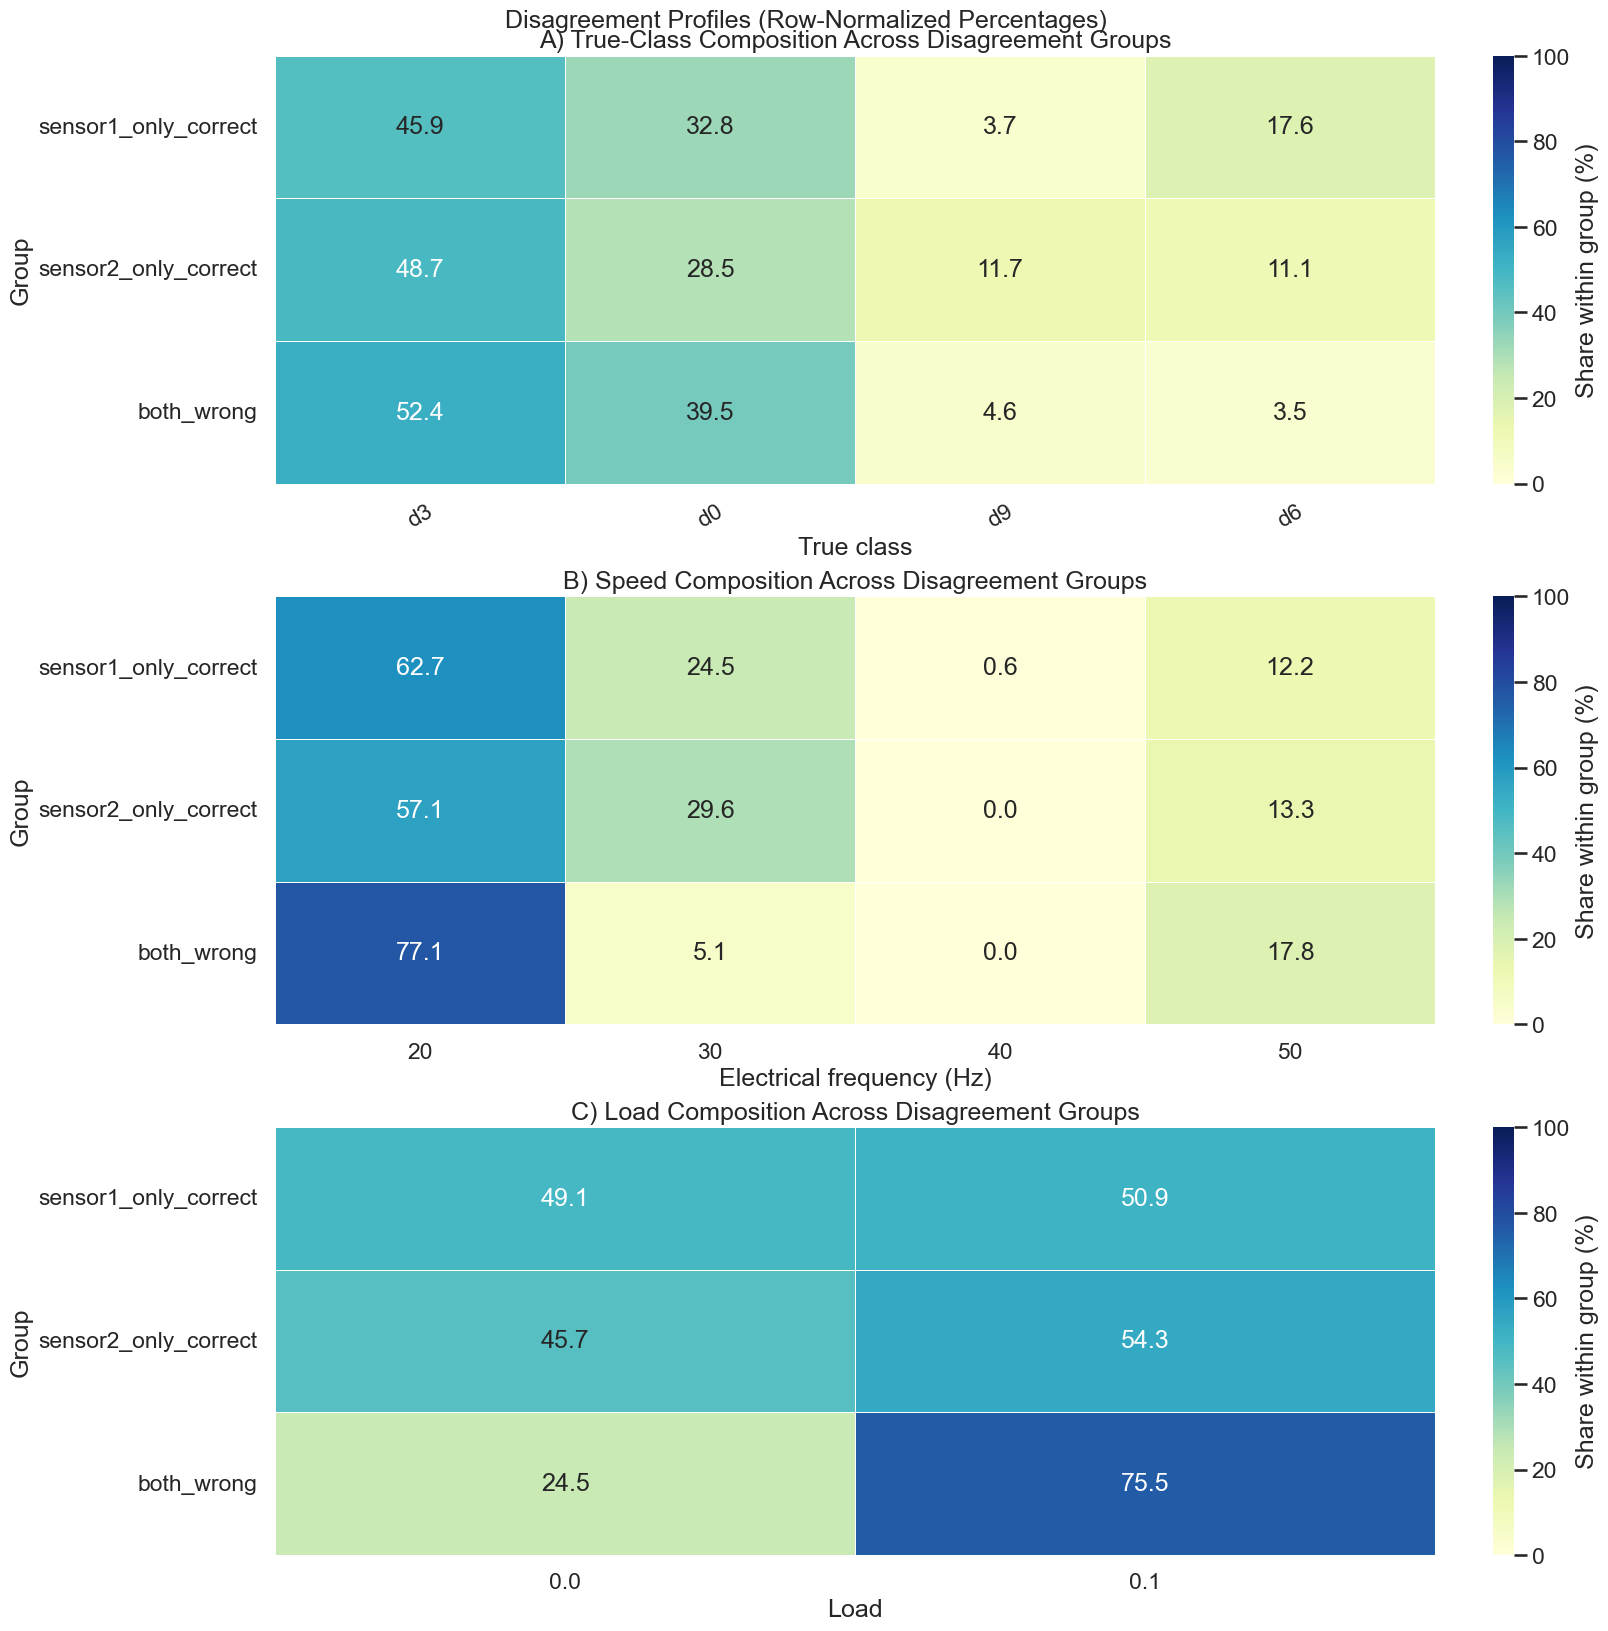

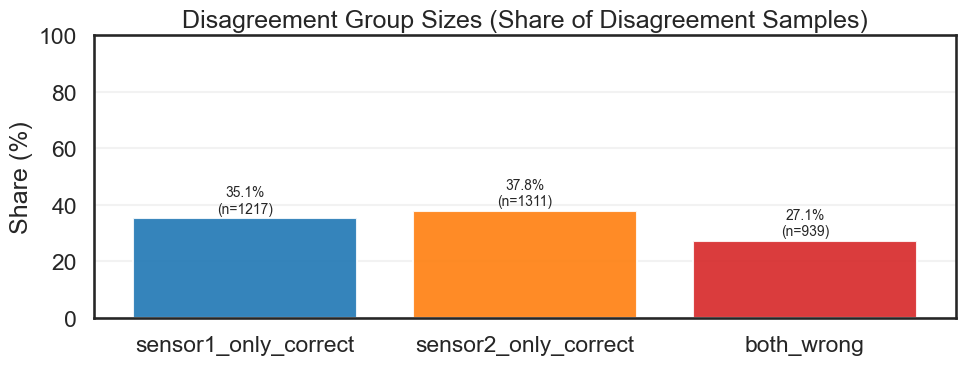

Stored article-ready normalized pivots under disagreement_analysis['article_pivots_pct'].


In [3]:
# Publication-style disagreement visuals (percent normalized)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if "disagreement_analysis" not in globals():
    raise RuntimeError("disagreement_analysis is missing. Run the disagreement diagnostics cell first.")

required_keys = {"class_counts", "freq_counts", "load_counts", "summary_counts"}
missing_keys = [k for k in required_keys if k not in disagreement_analysis]
if missing_keys:
    raise KeyError(f"disagreement_analysis is missing keys: {missing_keys}")

class_counts = disagreement_analysis["class_counts"].copy()
freq_counts = disagreement_analysis["freq_counts"].copy()
load_counts = disagreement_analysis["load_counts"].copy()
summary_counts = disagreement_analysis["summary_counts"].copy()

# Keep order stable across all figures.
group_order = ["sensor1_only_correct", "sensor2_only_correct", "both_wrong"]


def _normalize_rows_to_pct(df: pd.DataFrame) -> pd.DataFrame:
    row_sums = df.sum(axis=1).replace(0.0, np.nan)
    return df.div(row_sums, axis=0).fillna(0.0) * 100.0


def _ordered_columns_for_class(df_long: pd.DataFrame) -> list:
    both_wrong_slice = df_long[df_long["group"] == "both_wrong"].copy()
    if both_wrong_slice.empty:
        return sorted(df_long["true_class"].dropna().unique().tolist())
    return (
        both_wrong_slice.sort_values("ratio", ascending=False)["true_class"]
        .drop_duplicates()
        .tolist()
    )


def _ordered_columns_for_speed(df_long: pd.DataFrame) -> list:
    vals = pd.to_numeric(df_long["electrical_frequency_hz"], errors="coerce")
    unique_vals = sorted(v for v in vals.dropna().unique().tolist())
    return unique_vals


def _ordered_columns_for_load(df_long: pd.DataFrame) -> list:
    raw_vals = df_long["load"].dropna().unique().tolist()
    numeric_vals = pd.to_numeric(pd.Series(raw_vals), errors="coerce")
    if numeric_vals.notna().all():
        return sorted(float(v) for v in numeric_vals.tolist())

    semantic_priority = ["no load", "under load", "unknown"]
    as_str = [str(v) for v in raw_vals]
    semantic = [v for v in semantic_priority if v in as_str]
    rest = sorted(v for v in as_str if v not in semantic_priority)
    return semantic + rest


# Build pivot tables from long tables.
class_cols = _ordered_columns_for_class(class_counts)
class_pivot = (
    class_counts.pivot_table(
        index="group",
        columns="true_class",
        values="ratio",
        aggfunc="sum",
    )
    .reindex(index=group_order, columns=class_cols)
    .fillna(0.0)
)

speed_cols = _ordered_columns_for_speed(freq_counts)
speed_pivot = (
    freq_counts.pivot_table(
        index="group",
        columns="electrical_frequency_hz",
        values="ratio",
        aggfunc="sum",
    )
    .reindex(index=group_order, columns=speed_cols)
    .fillna(0.0)
)

load_cols = _ordered_columns_for_load(load_counts)
load_pivot = (
    load_counts.pivot_table(
        index="group",
        columns="load",
        values="ratio",
        aggfunc="sum",
    )
    .reindex(index=group_order, columns=load_cols)
    .fillna(0.0)
)

# Safety normalization in case upstream ratios were affected by filtering.
class_pct = _normalize_rows_to_pct(class_pivot)
speed_pct = _normalize_rows_to_pct(speed_pivot)
load_pct = _normalize_rows_to_pct(load_pivot)

sns.set_theme(style="white", context="talk")

fig, axes = plt.subplots(3, 1, figsize=(16, 16), constrained_layout=True)

heatmap_kwargs = dict(
    cmap="YlGnBu",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Share within group (%)"},
)

sns.heatmap(class_pct, ax=axes[0], annot=True, fmt=".1f", **heatmap_kwargs)
axes[0].set_title("A) True-Class Composition Across Disagreement Groups")
axes[0].set_xlabel("True class")
axes[0].set_ylabel("Group")
axes[0].tick_params(axis="x", rotation=30)

sns.heatmap(speed_pct, ax=axes[1], annot=True, fmt=".1f", **heatmap_kwargs)
axes[1].set_title("B) Speed Composition Across Disagreement Groups")
axes[1].set_xlabel("Electrical frequency (Hz)")
axes[1].set_ylabel("Group")
axes[1].tick_params(axis="x", rotation=0)

sns.heatmap(load_pct, ax=axes[2], annot=True, fmt=".1f", **heatmap_kwargs)
axes[2].set_title("C) Load Composition Across Disagreement Groups")
axes[2].set_xlabel("Load")
axes[2].set_ylabel("Group")
axes[2].tick_params(axis="x", rotation=0)

fig.suptitle(
    "Disagreement Profiles (Row-Normalized Percentages)",
    fontsize=18,
    y=1.01,
)
plt.show()

# Context chart: absolute disagreement-group size share in the selected pair.
summary_for_plot = summary_counts.copy().set_index("group").reindex(group_order).fillna(0)
total_focus = float(summary_for_plot["count"].sum())
summary_for_plot["pct_of_focus"] = np.where(
    total_focus > 0,
    summary_for_plot["count"] / total_focus * 100.0,
    0.0,
)

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ["#1f77b4", "#ff7f0e", "#d62728"]
bars = ax.bar(summary_for_plot.index.tolist(), summary_for_plot["pct_of_focus"], color=bar_colors, alpha=0.9)
ax.set_title("Disagreement Group Sizes (Share of Disagreement Samples)")
ax.set_ylabel("Share (%)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.25)

for b, pct, cnt in zip(bars, summary_for_plot["pct_of_focus"], summary_for_plot["count"]):
    ax.text(
        b.get_x() + b.get_width() / 2,
        min(99.0, b.get_height() + 1.0),
        f"{pct:.1f}%\n(n={int(cnt)})",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

# Persist prepared pivots for export or reuse in later cells.
disagreement_analysis["article_pivots_pct"] = {
    "class_pct": class_pct,
    "speed_pct": speed_pct,
    "load_pct": load_pct,
}
print("Stored article-ready normalized pivots under disagreement_analysis['article_pivots_pct'].")